In [1]:
# 1. Import libraries and establish global settings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter  # to display axis percentage vs decimal values

# Global display and plotting settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

In [2]:
# 2. Load Excel worksheets

# File location
file_path = (
    "EIA Form 112 Data (Last Upd. 6_10_2026) "
    "[Make a copy to edit].xlsx"
)

# Read relevant worksheets
iou = pd.read_excel(
    file_path,
    sheet_name="2024-IOUs"
)

muni = pd.read_excel(
    file_path,
    sheet_name="2024-MUNIS"
)

coop = pd.read_excel(
    file_path,
    sheet_name="2024-COOPS"
)

In [3]:
# 3. Inspect original datasets

# Investor-owned utilities

print("\n--- IOU DATA ---")
print("Shape:", iou.shape)
iou.info()

print("\nFirst five rows:")
print(iou.head())

print("\nColumns:")
print(iou.columns.tolist())


# Municipal utilities

print("\n--- MUNICIPAL DATA ---")
print("Shape:", muni.shape)
muni.info()

print("\nFirst five rows:")
print(muni.head())

print("\nColumns:")
print(muni.columns.tolist())


# Cooperative utilities

print("\n--- COOPERATIVE DATA ---")
print("Shape:", coop.shape)
coop.info()

print("\nFirst five rows:")
print(coop.head())

print("\nColumns:")
print(coop.columns.tolist())


--- IOU DATA ---
Shape: (169, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   State                            169 non-null    object 
 1   Ownership                        169 non-null    object 
 2   Utility                          169 non-null    object 
 3   Holding Company                  169 non-null    object 
 4   Number of Customers              169 non-null    int64  
 5   2024 Disconnection Rate          169 non-null    float64
 6   Total 2024 Disconnections        169 non-null    float64
 7   Ranking (by Disconnection Rate)  169 non-null    int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 10.7+ KB

First five rows:
  State       Ownership                         Utility                 Holding Company  Number of Customers  \
0    MN  Investor Owned  Northwestern Wisconsin E

In [4]:
# 4. Harmonize variable names

# Rename IOU variables
iou = iou.rename(columns={
    "State": "state",
    "Utility": "utility_name",
    "Number of Customers": "customer_count",
    "Total 2024 Disconnections": "shutoffs",
    "2024 Disconnection Rate": "disconnection_rate"
})

# Convert IOU disconnection rate from percentage points
# to a decimal proportion
iou["disconnection_rate"] = (
    iou["disconnection_rate"] / 100
)

# Rename public-power rate variable
muni = muni.rename(columns={
    "shutoff_rate": "disconnection_rate"
})

coop = coop.rename(columns={
    "shutoff_rate": "disconnection_rate"
})

# Create common ownership variable
iou["producer_type"] = "Investor-Owned"
muni["producer_type"] = "Municipal"
coop["producer_type"] = "Cooperative"


# Retain variables needed for EDA
analysis_columns = [
    "state",
    "utility_name",
    "customer_count",
    "shutoffs",
    "disconnection_rate",
    "producer_type"
]

iou_analysis = iou[analysis_columns].copy()
muni_analysis = muni[analysis_columns].copy()
coop_analysis = coop[analysis_columns].copy()

In [5]:
# 5. Combine IOU, municipal, and cooperative data

df = pd.concat(
    [
        iou_analysis,
        muni_analysis,
        coop_analysis
    ],
    ignore_index=True  # needed to establish fresh index to new df
)

# Establish desired ordering
producer_order = [
    "Investor-Owned",
    "Municipal",
    "Cooperative"
]

df["producer_type"] = pd.Categorical(
    df["producer_type"],
    categories=producer_order,
    ordered=True
)

# Inspect combined dataset
print("\n--- COMBINED DATA ---")
print(df.head())

print("\nShape:")
print(df.shape)

print("\nUtilities by producer type:")
print(
    df["producer_type"]
    .value_counts()
    .reindex(producer_order)
)


--- COMBINED DATA ---
  state                    utility_name  customer_count  shutoffs  disconnection_rate   producer_type
0    MN  Northwestern Wisconsin Elec Co            88.0       0.0            0.000000  Investor-Owned
1    NY   Fishers Island Utility Co Inc           657.0       0.0            0.000000  Investor-Owned
2    IA        Amana Society Service Co           713.0       1.0            0.001403  Investor-Owned
3    HI            Maui Electric Co LTD         61811.0     138.0            0.002233  Investor-Owned
4    NY  Central Hudson Gas & Elec Corp        275025.0     733.0            0.002665  Investor-Owned

Shape:
(1122, 6)

Utilities by producer type:
producer_type
Investor-Owned    169
Municipal         444
Cooperative       509
Name: count, dtype: int64


In [6]:
# 6. Check missing values, duplicates, and invalid values

# Overall
print("\n--- MISSING VALUES ---")

missing_overall = df.isna().sum()

print(missing_overall)

# By producer type
missing_by_type = (
    df.isna()
      .groupby(
          df["producer_type"],
          observed=True
      )
      .sum()
)

print("\nMissing values by producer type:")
print(missing_by_type)

# Check for duplicates
duplicates = df.duplicated(
    subset=[
        "state",
        "utility_name",
        "producer_type"
    ],
    keep=False
)

print("\nNumber of possible duplicate rows:")
print(duplicates.sum())

print("\nPossible duplicates:")
print(
    df.loc[duplicates]
      .sort_values([
          "producer_type",
          "state",
          "utility_name"
      ])
)

# Confirm analytical variables are numeric
numeric_columns = [
    "customer_count",
    "shutoffs",
    "disconnection_rate"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# Check for suspect values
print("\nCustomer counts <= 0:")
print(
    df[df["customer_count"] <= 0]
)

print("\nNegative disconnections:")
print(
    df[df["shutoffs"] < 0]
)

print("\nNegative disconnection rates:")
print(
    df[df["disconnection_rate"] < 0]
)

print("\nDisconnection rates greater than 100%:")

high_rates = df[
    df["disconnection_rate"] > 1
]

print(
    high_rates[
        [
            "state",
            "utility_name",
            "producer_type",
            "customer_count",
            "shutoffs",
            "disconnection_rate"
        ]
    ]
)

print(
    high_rates["producer_type"].value_counts()
)

# Save cleaned and QC'd combined dataset dataframe
df.to_csv('cleaned_df.csv', index=False)


--- MISSING VALUES ---
state                 0
utility_name          0
customer_count        0
shutoffs              0
disconnection_rate    0
producer_type         0
dtype: int64

Missing values by producer type:
                state  utility_name  customer_count  shutoffs  disconnection_rate  producer_type
producer_type                                                                                   
Investor-Owned      0             0               0         0                   0              0
Municipal           0             0               0         0                   0              0
Cooperative         0             0               0         0                   0              0

Number of possible duplicate rows:
0

Possible duplicates:
Empty DataFrame
Columns: [state, utility_name, customer_count, shutoffs, disconnection_rate, producer_type]
Index: []

Customer counts <= 0:
Empty DataFrame
Columns: [state, utility_name, customer_count, shutoffs, disconnection_rate, produc

In [7]:
df["disconnection_rate"].max().round(4)

0.8618

No utilities have reported disconnection rates greater than 100% after harmonizing the rate scales across the three ownership types. The maximum observed disconnection rate is approximately 86.18%.

In [8]:
# 7. Validate disconnection-rate calculations

Independently calculate
$$\hat{r}_i = \frac{D_i}{C_i}$$
where $D_i$ is disconnections and $C_i$ is customer count for utility $i$

In [9]:
# Independently calculate rate
df["calculated_rate"] = (
    df["shutoffs"] /
    df["customer_count"]
)

# Difference between reported and calculated rate
df["rate_difference"] = (
    df["disconnection_rate"] -
    df["calculated_rate"]
)

print("\n--- RATE VALIDATION ---")

print(
    df[
        [
            "utility_name",
            "producer_type",
            "disconnection_rate",
            "calculated_rate",
            "rate_difference"
        ]
    ].head(20)
)

print("\nRate difference summary:")
print(
    df["rate_difference"].describe()
)

# Identify largest discrepancies
df["absolute_rate_difference"] = (
    df["rate_difference"].abs()
)

largest_differences = (
    df.sort_values(
        "absolute_rate_difference",
        ascending=False
    )
    [
        [
            "state",
            "utility_name",
            "producer_type",
            "disconnection_rate",
            "calculated_rate",
            "rate_difference"
        ]
    ]
    .head(20)
)

print("\nLargest rate discrepancies:")
print(largest_differences)


--- RATE VALIDATION ---
                      utility_name   producer_type  disconnection_rate  calculated_rate  rate_difference
0   Northwestern Wisconsin Elec Co  Investor-Owned            0.000000         0.000000     0.000000e+00
1    Fishers Island Utility Co Inc  Investor-Owned            0.000000         0.000000     0.000000e+00
2         Amana Society Service Co  Investor-Owned            0.001403         0.001403    -1.795231e-13
3             Maui Electric Co LTD  Investor-Owned            0.002233         0.002233     1.504980e-08
4   Central Hudson Gas & Elec Corp  Investor-Owned            0.002665         0.002665    -2.422432e-09
5       North Central Power Co Inc  Investor-Owned            0.002805         0.002805     4.683564e-08
6      Empire District Electric Co  Investor-Owned            0.002886         0.002886    -6.803478e-09
7            Nantucket Electric Co  Investor-Owned            0.003587         0.003587    -2.331301e-08
8    Consolidated Edison Co-Ny

In [10]:
# 8. Calculate descriptive statistics

# Calculate basic descriptive statistics for the main numerical variables
print("\n--- OVERALL DESCRIPTIVE STATISTICS ---")

print(
    df[
        [
            "customer_count",
            "shutoffs",
            "disconnection_rate"
        ]
    ].describe()
)

# Disconnection rates summarized by ownership type
rate_summary = (
    df.groupby(
        "producer_type",
        observed=True
    )["disconnection_rate"]
    .describe()
)

print("\nDisconnection rate summary by producer type:")
print(rate_summary)

# Focused summary table
group_summary = (
    df.groupby(
        "producer_type",
        observed=True
    )
    .agg(
        utility_count=("utility_name", "count"),
        total_customers=("customer_count", "sum"),
        total_disconnections=("shutoffs", "sum"),
        mean_rate=("disconnection_rate", "mean"),
        median_rate=("disconnection_rate", "median"),
        std_rate=("disconnection_rate", "std"),
        min_rate=("disconnection_rate", "min"),
        max_rate=("disconnection_rate", "max")
    )
)

# Calculate Q1, Q3, and IQR
quartiles = (
    df.groupby(
        "producer_type",
        observed=True
    )["disconnection_rate"]
    .quantile([0.25, 0.75])
    .unstack()
)

quartiles.columns = [
    "q1_rate",
    "q3_rate"
]

group_summary = group_summary.join(
    quartiles
)

group_summary["IQR"] = (
    group_summary["q3_rate"] -
    group_summary["q1_rate"]
)

print("\nGroup summary:")
print(group_summary)


--- OVERALL DESCRIPTIVE STATISTICS ---
       customer_count      shutoffs  disconnection_rate
count    1.122000e+03  1.122000e+03         1122.000000
mean     1.129413e+05  1.074843e+04            0.093717
std      4.032197e+05  6.451333e+04            0.118579
min      2.100000e+01  0.000000e+00            0.000000
25%      6.492708e+03  2.030000e+02            0.021754
50%      1.631808e+04  9.275000e+02            0.051760
75%      4.045469e+04  3.605000e+03            0.123058
max      5.297328e+06  1.241425e+06            0.861840

Disconnection rate summary by producer type:
                count      mean       std       min       25%       50%       75%       max
producer_type                                                                              
Investor-Owned  169.0  0.063445  0.076834  0.000000  0.022770  0.038759  0.069188  0.583137
Municipal       444.0  0.123152  0.137523  0.000653  0.029103  0.079675  0.159098  0.774155
Cooperative     509.0  0.078092  0.106190 

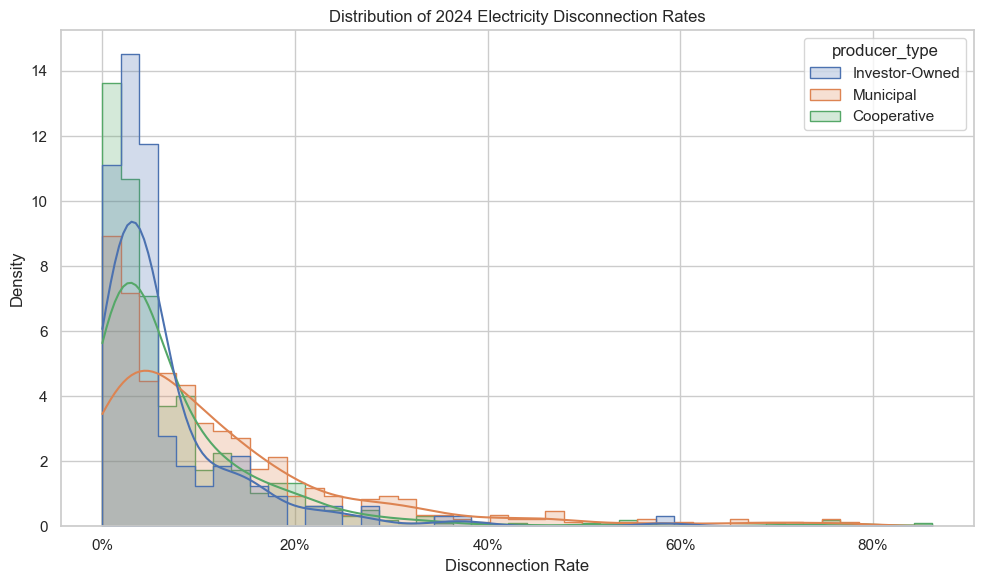

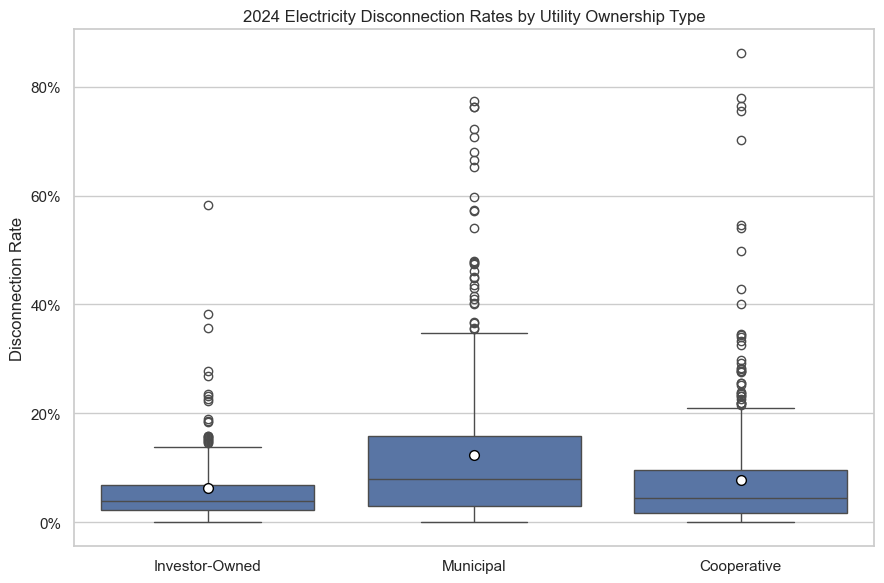


Potential outliers:
    state                       utility_name   producer_type  customer_count  shutoffs  disconnection_rate
613    KY         South Kentucky Rural E C C     Cooperative    6.456300e+04   55643.0            0.861840
614    IN  Jackson County Rural E M C - (IN)     Cooperative    2.067750e+04   16115.0            0.779350
169    GA                    City of Camilla       Municipal    2.481417e+03    1921.0            0.774155
615    AR     South Central Ark El Coop, Inc     Cooperative    6.023000e+03    4602.0            0.764071
170    AL          Sylacauga Utilities Board       Municipal    5.124917e+03    3907.0            0.762354
..    ...                                ...             ...             ...       ...                 ...
152    NV                    Nevada Power Co  Investor-Owned    9.163850e+05  139553.0            0.152286
151    FL           Duke Energy Florida, Llc  Investor-Owned    1.820759e+06  275826.0            0.151490
150    AR       

In [11]:
# 9. Examine distributions and outliers

# Histogram/KDE
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="disconnection_rate",
    hue="producer_type",
    hue_order=producer_order,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title(
    "Distribution of 2024 Electricity Disconnection Rates"
)
plt.xlabel("Disconnection Rate")
plt.ylabel("Density")

plt.gca().xaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

plt.tight_layout()

plt.savefig(
    "disconnection_rate_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Box-and-whisker plot with mean marker (combines the distributional comparison with the mean-versus-median comparison)
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="producer_type",
    y="disconnection_rate",
    order=producer_order,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 7
    }
)

plt.title(
    "2024 Electricity Disconnection Rates "
    "by Utility Ownership Type"
)
plt.xlabel("")
plt.ylabel("Disconnection Rate")

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

plt.tight_layout()

plt.savefig(
    "disconnection_rates_by_ownership.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Identify potential outliers
outlier_limits = quartiles.copy()

outlier_limits["IQR"] = (
    outlier_limits["q3_rate"] -
    outlier_limits["q1_rate"]
)

outlier_limits["lower_bound"] = (
    outlier_limits["q1_rate"] -
    1.5 * outlier_limits["IQR"]
)

outlier_limits["upper_bound"] = (
    outlier_limits["q3_rate"] +
    1.5 * outlier_limits["IQR"]
)

df = df.merge(
    outlier_limits[
        ["lower_bound", "upper_bound"]
    ],
    left_on="producer_type",
    right_index=True,
    how="left"
)

df["potential_outlier"] = (
    (df["disconnection_rate"] < df["lower_bound"]) |
    (df["disconnection_rate"] > df["upper_bound"])
)

outliers = df[
    df["potential_outlier"]
].copy()

print("\nPotential outliers:")
print(
    outliers[
        [
            "state",
            "utility_name",
            "producer_type",
            "customer_count",
            "shutoffs",
            "disconnection_rate"
        ]
    ]
    .sort_values(
        "disconnection_rate",
        ascending=False
    )
)

# Number of potential outliers by producer type
outliers_by_type = (
    outliers["producer_type"]
    .value_counts()
    .reindex([
        "Investor-Owned",
        "Municipal",
        "Cooperative"
    ])
)

print("\n--- POTENTIAL OUTLIERS BY PRODUCER TYPE ---")
print(outliers_by_type)

print("\nTotal potential outliers:", outliers_by_type.sum())

Although no disconnection rates greater than 100% are observed in the corrected dataset, such a rate could theoretically occur because the numerator represents disconnection events rather than necessarily unique customers disconnected.

In [12]:
# 10. Compare means, medians, IQRs, and distributional overlap

ownership_comparison = (
    group_summary[
        [
            "utility_count",
            "mean_rate",
            "median_rate",
            "q1_rate",
            "q3_rate",
            "IQR"
        ]
    ]
    .copy()
)

rate_cols = [
    "mean_rate",
    "median_rate",
    "q1_rate",
    "q3_rate",
    "IQR"
]

ownership_comparison[rate_cols] = (
    ownership_comparison[rate_cols] * 100
)

ownership_comparison = (
    ownership_comparison.rename(
        columns={
            "utility_count": "Number of Utilities",
            "mean_rate": "Mean (%)",
            "median_rate": "Median (%)",
            "q1_rate": "Q1 (%)",
            "q3_rate": "Q3 (%)",
            "IQR": "IQR (percentage points)"
        }
    )
)

print("\n--- OWNERSHIP COMPARISON ---")
print(
    ownership_comparison.round(2)
)

# Mean vs Median
mean_median = (
    df.groupby(
        "producer_type",
        observed=True
    )["disconnection_rate"]
    .agg(["mean", "median"])
)

mean_median["mean_minus_median"] = (
    mean_median["mean"] -
    mean_median["median"]
)

print("\nMean vs. median:")
print(
    (mean_median * 100).round(2)
)

# IQR overlap
def iqr_overlap(group1, group2):

    lower = max(
        quartiles.loc[group1, "q1_rate"],
        quartiles.loc[group2, "q1_rate"]
    )

    upper = min(
        quartiles.loc[group1, "q3_rate"],
        quartiles.loc[group2, "q3_rate"]
    )

    overlap = max(
        0,
        upper - lower
    )

    return overlap

iou_muni_overlap = iqr_overlap(
    "Investor-Owned",
    "Municipal"
)

iou_coop_overlap = iqr_overlap(
    "Investor-Owned",
    "Cooperative"
)

muni_coop_overlap = iqr_overlap(
    "Municipal",
    "Cooperative"
)

print("\nIQR overlap:")

print(
    "IOU vs. Municipal:",
    round(iou_muni_overlap * 100, 2),
    "percentage points"
)

print(
    "IOU vs. Cooperative:",
    round(iou_coop_overlap * 100, 2),
    "percentage points"
)

print(
    "Municipal vs. Cooperative:",
    round(muni_coop_overlap * 100, 2),
    "percentage points"
)


--- OWNERSHIP COMPARISON ---
                Number of Utilities  Mean (%)  Median (%)  Q1 (%)  Q3 (%)  IQR (percentage points)
producer_type                                                                                     
Investor-Owned                  169      6.34        3.88    2.28    6.92                     4.64
Municipal                       444     12.32        7.97    2.91   15.91                    13.00
Cooperative                     509      7.81        4.39    1.65    9.61                     7.95

Mean vs. median:
                 mean  median  mean_minus_median
producer_type                                   
Investor-Owned   6.34    3.88               2.47
Municipal       12.32    7.97               4.35
Cooperative      7.81    4.39               3.42

IQR overlap:
IOU vs. Municipal: 4.01 percentage points
IOU vs. Cooperative: 4.64 percentage points
Municipal vs. Cooperative: 6.7 percentage points



--- UTILITY SIZE ---
                count       mean     median     min         max
producer_type                                                  
Investor-Owned    169  581566.01  275025.00   70.00  5297328.00
Municipal         444   27735.05    9815.58  193.08  1440137.83
Cooperative       509   31672.21   18897.42   21.00   381493.75


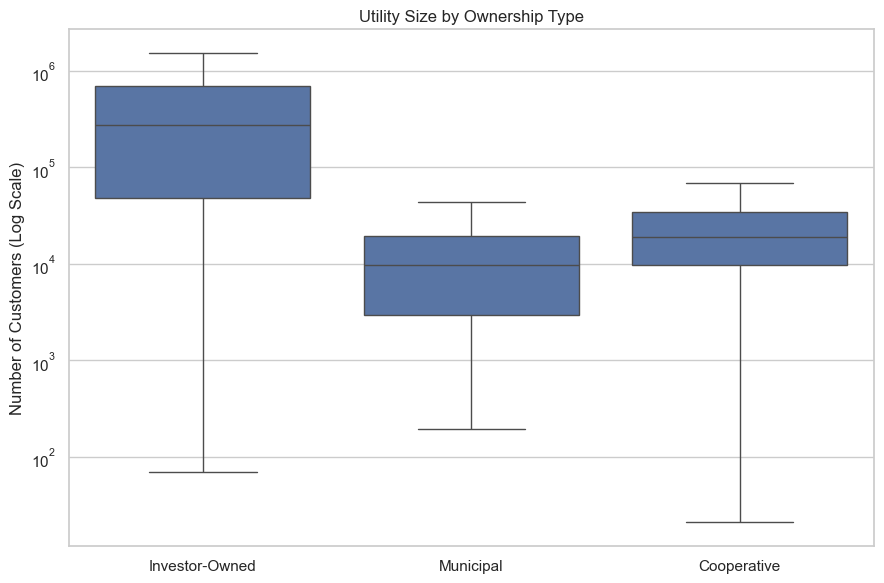

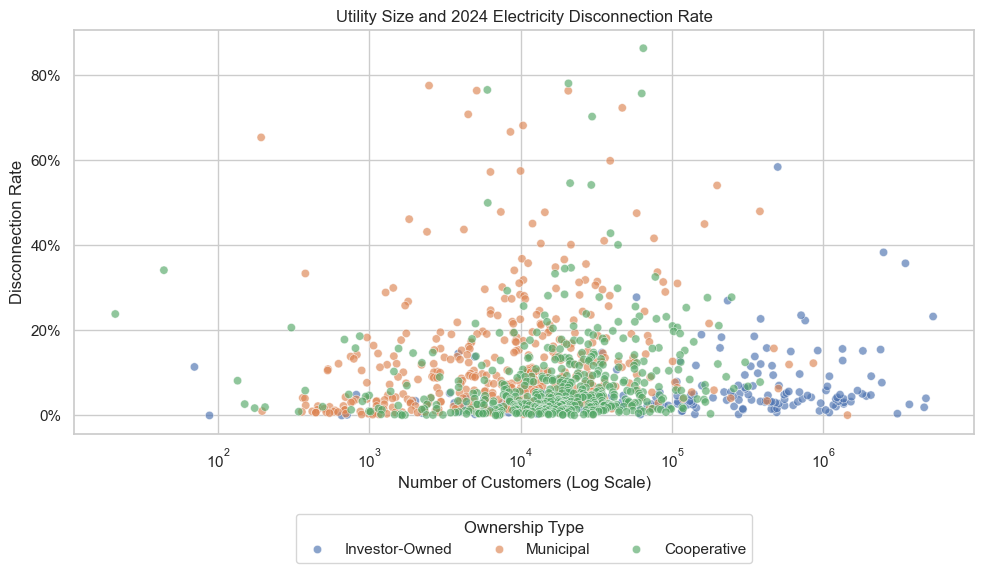

In [13]:
# 11. Examine utility size

# Customer counts summarized by ownership type
size_summary = (
    df.groupby(
        "producer_type",
        observed=True
    )["customer_count"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
)

print("\n--- UTILITY SIZE ---")
print(size_summary.round(2))

# Utility size distribution
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="producer_type",
    y="customer_count",
    order=producer_order,
    showfliers=False
)

plt.yscale("log")

plt.title(
    "Utility Size by Ownership Type"
)
plt.xlabel("")
plt.ylabel(
    "Number of Customers (Log Scale)"
)

plt.tight_layout()

plt.savefig(
    "utility_size_by_ownership.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Utility size versus disconnection rate
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="customer_count",
    y="disconnection_rate",
    hue="producer_type",
    hue_order=producer_order,
    alpha=0.65
)

plt.xscale("log")

plt.title(
    "Utility Size and 2024 Electricity "
    "Disconnection Rate"
)
plt.xlabel(
    "Number of Customers (Log Scale)"
)
plt.ylabel("Disconnection Rate")

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

plt.legend(
    title="Ownership Type",
    bbox_to_anchor=(0.5, -0.18),
    loc="upper center",
    ncol=3
)

plt.tight_layout()

plt.savefig(
    "utility_size_vs_disconnection_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


--- UTILITIES BY STATE AND OWNERSHIP ---
producer_type  Investor-Owned  Municipal  Cooperative
state                                                
AK                          2          1            8
AL                          1         13           15
AR                          4         10           13
AZ                          5          2            4
CA                          4         15            1
CO                          2          7           21
CT                          2          4            0
DC                          1          0            0
DE                          1          3            1
FL                          4         14           13
GA                          1         19           27
HI                          3          0            1
IA                          3         22           15
ID                          3          1            7
IL                          4         13           12
IN                          4         12

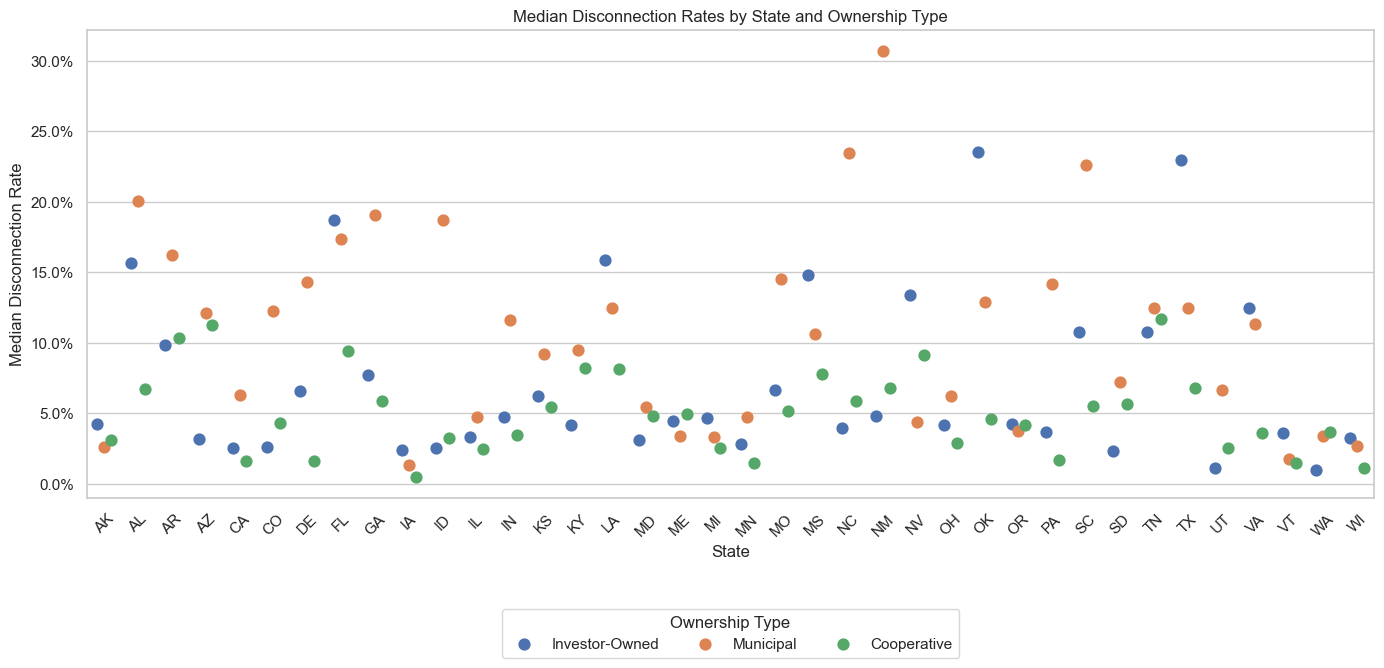

In [14]:
# 12. Examine geographic/state patterns

# Utility ownership type count by state
state_counts = pd.crosstab(
    df["state"],
    df["producer_type"]
)

print("\n--- UTILITIES BY STATE AND OWNERSHIP ---")
print(state_counts)

# States represented by all three ownership types
states_all_three = state_counts[
    (state_counts > 0).all(axis=1)
].index

print("\nStates containing all three ownership types:")
print(
    states_all_three.tolist()
)
print("Count:", len(states_all_three))

state_compare = df[
    df["state"].isin(states_all_three)
].copy()

state_medians = (
    state_compare
    .groupby(
        [
            "state",
            "producer_type"
        ],
        observed=True
    )["disconnection_rate"]
    .median()
    .reset_index()
)

print("\nState median rates:")
print(state_medians)

# Visualization
plt.figure(figsize=(14, 7))

sns.pointplot(
    data=state_medians,
    x="state",
    y="disconnection_rate",
    hue="producer_type",
    hue_order=producer_order,
    errorbar=None,
    linestyles="none",
    dodge=0.4
)

plt.title(
    "Median Disconnection Rates "
    "by State and Ownership Type"
)
plt.xlabel("State")
plt.ylabel(
    "Median Disconnection Rate"
)

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

plt.xticks(rotation=45)

plt.legend(
    title="Ownership Type",
    bbox_to_anchor=(0.5, -0.22),
    loc="upper center",
    ncol=3
)

plt.tight_layout()

plt.savefig(
    "median_disconnection_rates_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [15]:
# 13. Compare unweighted and aggregate rates

Calculate the aggregate rate for each ownership type
$$R_g= \frac{\sum_i{D_{ig}}}{\sum_i{C_{ig}}}$$


--- MEAN VS. AGGREGATE RATE ---
                mean_rate  aggregate_rate
producer_type                            
Investor-Owned       6.34            8.98
Municipal           12.32           13.59
Cooperative          7.81            9.65


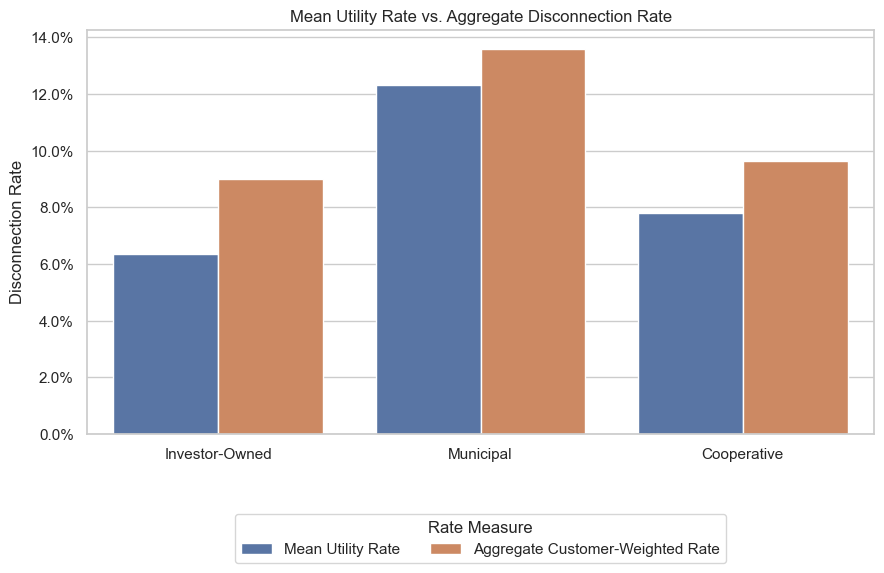

In [16]:
group_summary["aggregate_rate"] = (
    group_summary["total_disconnections"] /
    group_summary["total_customers"]
)

print("\n--- MEAN VS. AGGREGATE RATE ---")

print(
    (
        group_summary[
            [
                "mean_rate",
                "aggregate_rate"
            ]
        ] * 100
    ).round(2)
)

comparison = (
    group_summary[
        [
            "mean_rate",
            "aggregate_rate"
        ]
    ]
    .reset_index()
    .melt(
        id_vars="producer_type",
        var_name="rate_measure",
        value_name="rate"
    )
)

comparison["rate_measure"] = (
    comparison["rate_measure"]
    .replace({
        "mean_rate":
            "Mean Utility Rate",
        "aggregate_rate":
            "Aggregate Customer-Weighted Rate"
    })
)

# Grouped bar chart
plt.figure(figsize=(9, 6))

sns.barplot(
    data=comparison,
    x="producer_type",
    y="rate",
    hue="rate_measure",
    order=producer_order
)

plt.title(
    "Mean Utility Rate vs. "
    "Aggregate Disconnection Rate"
)
plt.xlabel("")
plt.ylabel("Disconnection Rate")

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

plt.legend(
    title="Rate Measure",
    bbox_to_anchor=(0.5, -0.18),
    loc="upper center",
    ncol=2
)

plt.tight_layout()

plt.savefig(
    "mean_vs_aggregate_disconnection_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


--- CORRELATION MATRIX ---
                    customer_count  shutoffs  disconnection_rate
customer_count               1.000     0.675               0.003
shutoffs                     0.675     1.000               0.174
disconnection_rate           0.003     0.174               1.000


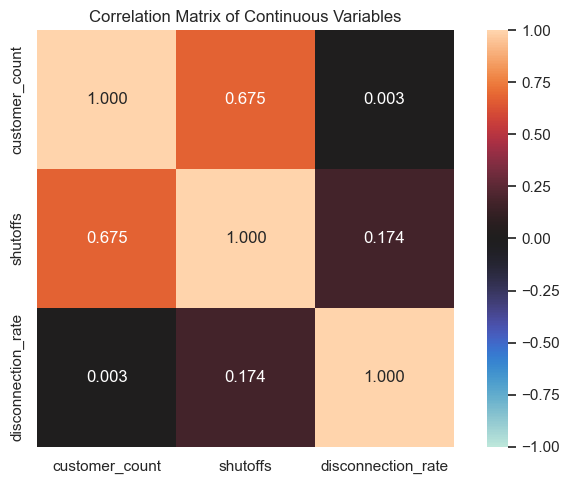


Correlation between customer count and disconnection rate:
0.003
Investor-Owned customer count vs. disconnection rate: 0.225
Municipal customer count vs. disconnection rate: 0.027
Cooperative customer count vs. disconnection rate: 0.128


In [17]:
# 14. Examine correlations among continuous variables

continuous_vars = df[
    [
        "customer_count",
        "shutoffs",
        "disconnection_rate"
    ]
]

correlation_matrix = (
    continuous_vars.corr(
        method="pearson"
    )
)

print("\n--- CORRELATION MATRIX ---")
print(
    correlation_matrix.round(3)
)

# Visualization
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

plt.title(
    "Correlation Matrix of Continuous Variables"
)

plt.tight_layout()

plt.savefig(
    "correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Customer count versus disconnection rate
size_rate_corr = (
    df[
        [
            "customer_count",
            "disconnection_rate"
        ]
    ]
    .corr()
    .loc[
        "customer_count",
        "disconnection_rate"
    ]
)

print(
    "\nCorrelation between customer count "
    "and disconnection rate:"
)

print(
    round(size_rate_corr, 3)
)

# Calculated by ownership type
for producer in producer_order:

    subset = df[
        df["producer_type"] == producer
    ]

    corr_matrix = subset[
        [
            "customer_count",
            "disconnection_rate"
        ]
    ].corr()

    corr = corr_matrix.loc[
        "customer_count",
        "disconnection_rate"
    ]

    print(
        producer,
        "customer count vs. disconnection rate:",
        round(corr, 3)
    )

In [18]:
# 15. Produce final summary table

# Create final summary table
final_summary = (
    group_summary[
        [
            "utility_count",
            "total_customers",
            "total_disconnections",
            "mean_rate",
            "median_rate",
            "q1_rate",
            "q3_rate",
            "IQR",
            "aggregate_rate"
        ]
    ]
    .copy()
)


# Convert rate variables from proportions to percentages
final_rate_columns = [
    "mean_rate",
    "median_rate",
    "q1_rate",
    "q3_rate",
    "IQR",
    "aggregate_rate"
]

final_summary[final_rate_columns] = (
    final_summary[final_rate_columns] * 100
)


# Rename columns for presentation
final_summary = (
    final_summary.rename(
        columns={
            "utility_count": "Utilities",
            "total_customers": "Total Customers",
            "total_disconnections": "Total Disconnections",
            "mean_rate": "Mean Rate (%)",
            "median_rate": "Median Rate (%)",
            "q1_rate": "Q1 (%)",
            "q3_rate": "Q3 (%)",
            "IQR": "IQR (percentage points)",
            "aggregate_rate": "Aggregate Rate (%)"
        }
    )
)


# Display final summary table
print("\n--- FINAL EDA SUMMARY ---")
print(
    final_summary.round(2)
)


--- FINAL EDA SUMMARY ---
                Utilities  Total Customers  Total Disconnections  Mean Rate (%)  Median Rate (%)  Q1 (%)  Q3 (%)  \
producer_type                                                                                                      
Investor-Owned        169      98284655.00            8830290.77           6.34             3.88    2.28    6.92   
Municipal             444      12314364.25            1673315.00          12.32             7.97    2.91   15.91   
Cooperative           509      16121154.33            1556134.00           7.81             4.39    1.65    9.61   

                IQR (percentage points)  Aggregate Rate (%)  
producer_type                                                
Investor-Owned                     4.64                8.98  
Municipal                         13.00               13.59  
Cooperative                        7.95                9.65  


In [19]:
# 16. Results interpretation

The exploratory data analysis (EDA) conducted indicates that 2024 electricity disconnection rates differ across the three utility ownership types, although there is substantial variation and overlap within the groups. Municipal utilities (MUNIs) have the highest mean disconnection rate at 12.32 disconnection events per 100 customers and the highest median at 7.97. Cooperative utilities (COOPs) have a mean of 7.81 and median of 4.39, while Investor-Owned Utilities (IOUs) have the lowest mean at 6.34 and median at 3.88. Thus, the largest descriptive difference occurs between MUNIs and IOUs, while COOPs and IOUs have considerably more similar typical rates. (Note: the rates are most precisely interpreted as disconnection events per 100 customers, rather than the percentage of unique customers who experienced a disconnection, because an individual customer may potentially experience more than one disconnection event during the year.)

The distributions also show considerable within-group variability, particularly among MUNIs and COOPs. MUNIs have the widest IQR at 13.00 disconnection events per 100 customers, compared with 7.95 for COOPs and 4.64 for IOUs. The mean exceeds the median for all three groups (by 4.35 disconnection events per 100 customers for MUNIs, 3.42 for COOPs, and 2.47 for IOUs), indicating right-skewed distributions in which utilities with unusually high disconnection rates raise the group means. The outlier analysis identified 85 potential outliers (21 of which are IOUS, 29 are MUNIs and 35 are COOPS), further supporting the importance of considering medians and IQRs rather than relying on means alone. Importantly, the IQRs overlap across every pair of ownership types: 4.01 disconnection events per 100 customers for IOU–MUNI, 4.64 for IOU–COOP, and 6.70 for MUNI–COOP. Therefore, ownership groups are not characterized by completely distinct disconnection-rate distributions.

Utility size differs substantially by ownership type. The median IOU serves approximately 275,025 customers, compared with about 9,816 for MUNIs and 18,897 for COOPs. However, utility size by itself does not appear to explain much of the variation in disconnection rates across the complete dataset. The Pearson correlation between customer count and disconnection rate is essentially zero ($r=0.003$). Within ownership groups, the relationship remains relatively weak, although it is somewhat larger for IOUs ($r=0.225$) than for COOPs ($r=0.128$) or MUNIs ($r=0.027$). In contrast, customer count is moderately positively correlated with the number of disconnections ($r=0.675$), which is expected because utilities serving more customers have more opportunities for disconnection events. This reinforces the decision to compare disconnection rates, rather than raw disconnection counts, across ownership types.

The aggregate customer-weighted results generally support the utility-level comparisons but also show that utility size affects the magnitude of the rates. The aggregate rates are 8.98 disconnection events per 100 customers for IOUs, 13.59 for MUNIs, and 9.65 for COOPs, compared with unweighted mean utility rates of 6.34, 12.32, and 7.81, respectively. The aggregate rate exceeds the unweighted mean for all three ownership types, indicating that larger utilities within each group tend collectively to contribute proportionally more disconnection events than would be suggested by treating every utility equally. Nevertheless, MUNIs have the highest rate under both approaches, while IOUs have the lowest, so the general ownership pattern is not reversed by accounting for customer base.

Geography also appears relevant to interpretation. 38 states in the dataset contain all three ownership types, allowing ownership comparisons within a common state context. The state-level median results vary across states rather than displaying a completely uniform national ownership pattern. Consequently, the higher overall municipal rate should not be interpreted as evidence that municipal ownership itself necessarily produces higher disconnection rates; geographic and other utility-specific conditions may contribute to the observed differences.

**Overall conclusion**

Taken together, the EDA provides descriptive evidence of an association between utility ownership type and 2024 electricity disconnection rates, with MUNIs exhibiting the highest typical rates, COOPs occupying a middle position, and IOUs exhibiting the lowest rates overall. However, substantial within-group variation, overlapping IQRs, outliers, and geographic variation show that ownership type alone does not cleanly separate utilities according to their disconnection rates. Utility size differs dramatically across ownership categories but has almost no overall linear correlation with the disconnection rate, suggesting that size alone is unlikely to account for the observed ownership differences. Because this analysis is exploratory, limited to one year (2024), and does not control for other factors such as state policies, customer characteristics, economic conditions, or utility disconnection practices, the findings should be interpreted as associations rather than causal effects of ownership type.